In [7]:
# 1. Import
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.base import clone
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
print('Da import thu vien')

Da import thu vien


In [ ]:
# 2. Duong dan va hang so
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR) if 'notebooks' in CURRENT_DIR else CURRENT_DIR

RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'DuLieuGiaNhaHCM2024.csv')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'best_model_v2.pkl')

TARGET_COL = 'Price'
IMPUTE_COLS = ['Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
REL_MAX = 0.25 

NUM_COLS = [
    'Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms',
    'Total_Bed_Bath', 'Rooms_per_Floor', 'Area_per_Room', 'Total_Usable_Area',
    'Frontage_Area_Ratio', 'Access_Road_Area_Ratio', 'Area_to_Dist_Med',
    'Area_log', 'Usable_Area_log', 'Area_sq',
    'Frontage_missing', 'AccessRoad_missing', 'Floors_missing',
    'Is_Alley', 'Is_Project',
    'Dist_Med_Price_m2', 'Ward_Med_Price_m2', 'Street_Med_Price_m2',
    'Naive_Price', 'Naive_Price_Ward', 'Naive_Price_Street',
]
CAT_COLS = [
    'Legal status', 'Furniture state', 'District', 'Ward',
    'Street_Clean', 'Property_Type',
]

print('Data:', RAW_DATA_PATH)
print('Model:', MODEL_SAVE_PATH)

Data: e:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\data\raw\DuLieuGiaNhaHCM2024.csv
Model: e:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\models\best_model_v2.pkl


In [ ]:
# 3. Doc CSV 
def load_raw(path):
    try:
        return pd.read_csv(path, sep='\t', encoding='utf-16')
    except Exception:
        try:
            return pd.read_csv(path, sep=None, engine='python', encoding='utf-16')
        except Exception:
            return pd.read_csv(path, sep=None, engine='python', encoding='utf-8-sig')


if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(RAW_DATA_PATH)

df_raw = load_raw(RAW_DATA_PATH)
print(f'Da tai: {df_raw.shape[0]} dong, {df_raw.shape[1]} cot')
display(df_raw.head())

Da tai: 11780 dong, 10 cot


,Address,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,2.0,2.0,3.0,Have certificate,Full,5.35
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,2.0,4.0,4.0,Have certificate,Full,6.90
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,NaN,NaN,2.0,2.0,2.0,Have certificate,Full,3.79
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.6,6.0,4.0,4.0,5.0,Have certificate,Full,7.99
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.5,5.0,2.0,6.0,5.0,Have certificate,Full,5.60


In [ ]:
# 4. Ham tach dia chi / loai hinh / loc outlier
def extract_address_parts(address):
    parts = [p.strip() for p in str(address).strip().split(',') if p.strip()]
    district = parts[-2] if len(parts) >= 2 else (parts[-1] if parts else 'Unknown')
    district = re.sub(r'[.\s]+$', '', district).strip()
    ward = parts[-3] if len(parts) >= 3 else (parts[-2] if len(parts) >= 2 else 'Unknown')
    street = parts[0] if parts else 'Unknown'
    return district, ward, street


def clean_street(street):
    s = str(street)
    s = re.sub(r'Dự án[^,]*(,|$)', '', s, flags=re.IGNORECASE)
    s = re.sub(r'^Hẻm\s*[\d./\-]+,?\s*', '', s, flags=re.IGNORECASE)
    s = re.sub(r'^(Đường|Duong)\s+', '', s, flags=re.IGNORECASE)
    s = re.sub(r'\s+', ' ', s).strip(' ,')
    return s if s else 'Unknown'


def parse_location(df):
    addr = df['Address'].astype(str)
    df['District'], df['Ward'], df['Street'] = zip(*addr.map(extract_address_parts))
    df['Is_Project'] = addr.str.contains(
        r'Dự án|Vinhomes|Masteri|Opal|Celadon|Grand Park|The Beverly',
        case=False, regex=True,
    ).astype(int)
    df['Is_Alley'] = addr.str.contains(r'Hẻm|hẻm|hem\s', case=False, regex=True).astype(int)
    df['Property_Type'] = np.where(df['Is_Project'] == 1, 'apartment', 'house')
    df['Street_Clean'] = df['Street'].map(clean_street)
    return df


def clean_frame(df):
    df = df.replace([np.inf, -np.inf], np.nan).drop_duplicates()
    if 'Bathroom' in df.columns and 'Bathrooms' not in df.columns:
        df = df.rename(columns={'Bathroom': 'Bathrooms'})

    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
    df['Area'] = pd.to_numeric(df['Area'], errors='coerce')
    for col in IMPUTE_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df[df[TARGET_COL].notna() & (df[TARGET_COL] > 0) & df['Area'].notna() & (df['Area'] > 0)].copy()
    df = parse_location(df)

    dist_counts = df['District'].value_counts()
    df['District'] = df['District'].replace(dist_counts[dist_counts < 10].index, 'Khác')
    ward_counts = df['Ward'].value_counts()
    df['Ward'] = df['Ward'].replace(ward_counts[ward_counts < 5].index, 'Khác')

  
    df = df[(df['Is_Project'] == 0) & df['Area'].between(25, 120) & df[TARGET_COL].between(2.0, 9.5)]
    df = df[df['Floors'].isna() | df['Floors'].between(1, 7)].copy()

    df['Price_m2'] = df[TARGET_COL] * 1000.0 / df['Area']
    kept = []
    for _, group in df.groupby('District'):
        q1, q3 = group['Price_m2'].quantile(0.25), group['Price_m2'].quantile(0.75)
        iqr = max(q3 - q1, 1e-6)
        kept.append(group[group['Price_m2'].between(q1 - 0.9 * iqr, q3 + 0.9 * iqr)])
    df = pd.concat(kept, ignore_index=True)

    naive = df.groupby('District')['Price_m2'].transform('median') * df['Area'] / 1000.0
    rel = (df[TARGET_COL] - naive).abs() / naive.replace(0, np.nan)
    df = df[rel <= REL_MAX].copy()

    for col in ['Legal status', 'Furniture state']:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip().replace({'': 'Unknown'})

    # Giu tin hieu thieu truoc khi impute
    df['Frontage_missing'] = df['Frontage'].isna().astype(int)
    df['AccessRoad_missing'] = df['Access Road'].isna().astype(int)
    df['Floors_missing'] = df['Floors'].isna().astype(int)
    return df


df = clean_frame(df_raw)
print(f'Sau clean: {len(df)} dong | du an={int(df["Is_Project"].sum())} | hem={int(df["Is_Alley"].sum())}')
print(df[['District', 'Ward', 'Street_Clean', 'Property_Type', 'Is_Alley', 'Price']].head())

Sau clean: 6301 dong | du an=0 | hem=255
     District           Ward     Street_Clean Property_Type  Is_Alley  Price
0  Bình Chánh  Xã Vĩnh Lộc B    D16/22/ ấp 4b         house         0    2.7
2  Bình Chánh  Xã Bình Chánh    Xã Bình Chánh         house         0    4.0
5  Bình Chánh  Xã Bình Chánh  Hoàng Phan Thái         house         0    2.2
6  Bình Chánh   Xã Bình Hưng               C3         house         0    2.1
9  Bình Chánh  Xã Vĩnh Lộc B    Xã Vĩnh Lộc B         house         0    3.8


In [ ]:
# 5. Feature helpers, split
def add_row_features(frame):
    out = frame.copy()
    beds = out['Bedrooms'].fillna(0)
    baths = out['Bathrooms'].fillna(0)
    out['Total_Bed_Bath'] = beds + baths
    floors_safe = np.where(out['Floors'].fillna(1) < 1, 1, out['Floors'].fillna(1))
    out['Rooms_per_Floor'] = out['Total_Bed_Bath'] / floors_safe
    out['Area_per_Room'] = out['Area'] / (out['Total_Bed_Bath'] + 1)
    out['Total_Usable_Area'] = out['Area'] * floors_safe
    area_safe = out['Area'].replace(0, np.nan)
    out['Frontage_Area_Ratio'] = (out['Frontage'] / area_safe).fillna(0)
    out['Access_Road_Area_Ratio'] = (out['Access Road'] / area_safe).fillna(0)
    out['Area_log'] = np.log1p(out['Area'])
    out['Usable_Area_log'] = np.log1p(out['Total_Usable_Area'])
    out['Area_sq'] = out['Area'] ** 2
    return out


def fit_train_stats(train_df, y_price):
    stats = {'impute_district': {}, 'impute_global': {}}
    for col in IMPUTE_COLS:
        stats['impute_district'][col] = train_df.groupby('District')[col].median().to_dict()
        stats['impute_global'][col] = float(train_df[col].median()) if train_df[col].notna().any() else 0.0

    stats['district_median_areas'] = train_df.groupby('District')['Area'].median().to_dict()
    tmp = train_df.copy()
    tmp['_pm2'] = y_price.values * 1000.0 / tmp['Area']
    stats['dist_price_m2'] = tmp.groupby('District')['_pm2'].median().to_dict()
    stats['ward_price_m2'] = tmp.groupby('Ward')['_pm2'].median().to_dict()
    stats['street_price_m2'] = tmp.groupby('Street_Clean')['_pm2'].median().to_dict()
    stats['global_price_m2'] = float(tmp['_pm2'].median())
    street_counts = train_df['Street_Clean'].value_counts()
    stats['rare_streets'] = street_counts[street_counts < 8].index.tolist()
    return stats


def apply_train_stats(frame, stats):
    out = frame.copy()
    for col in IMPUTE_COLS:
        mapped = out['District'].map(stats['impute_district'][col])
        out[col] = out[col].fillna(mapped).fillna(stats['impute_global'][col])

    out['Street_Clean'] = out['Street_Clean'].where(~out['Street_Clean'].isin(stats['rare_streets']), 'Khác')
    out = add_row_features(out)
    dist_med_area = out['District'].map(stats['district_median_areas'])
    out['Area_to_Dist_Med'] = (out['Area'] / dist_med_area.replace(0, np.nan)).fillna(1.0)
    out['Dist_Med_Price_m2'] = out['District'].map(stats['dist_price_m2']).fillna(stats['global_price_m2'])
    out['Ward_Med_Price_m2'] = out['Ward'].map(stats['ward_price_m2']).fillna(stats['global_price_m2'])
    out['Street_Med_Price_m2'] = out['Street_Clean'].map(stats['street_price_m2']).fillna(out['Ward_Med_Price_m2'])
    out['Naive_Price'] = out['Area'] * out['Dist_Med_Price_m2'] / 1000.0
    out['Naive_Price_Ward'] = out['Area'] * out['Ward_Med_Price_m2'] / 1000.0
    out['Naive_Price_Street'] = out['Area'] * out['Street_Med_Price_m2'] / 1000.0
    return out


y_price = df[TARGET_COL].astype(float)
price_bin = pd.qcut(y_price, q=5, labels=False, duplicates='drop')
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=price_bin,
)

train_raw = df.iloc[idx_train].reset_index(drop=True)
test_raw = df.iloc[idx_test].reset_index(drop=True)
y_train_price = y_price.iloc[idx_train].reset_index(drop=True)
y_test_price = y_price.iloc[idx_test].reset_index(drop=True)

stats = fit_train_stats(train_raw, y_train_price)
train_fe = apply_train_stats(train_raw, stats)
test_fe = apply_train_stats(test_raw, stats)

num_cols = [c for c in NUM_COLS if c in train_fe.columns]
cat_cols = [c for c in CAT_COLS if c in train_fe.columns]
X_train = train_fe[num_cols + cat_cols]
X_test = test_fe[num_cols + cat_cols]
y_train_log = np.log1p(y_train_price.to_numpy())

print(f'Train={len(X_train)} | Test={len(X_test)} | features={X_train.shape[1]}')
print('So / phan loai:', len(num_cols), '/', len(cat_cols))

Train=5040 | Test=1261 | features=33
So / phan loai: 27 / 6


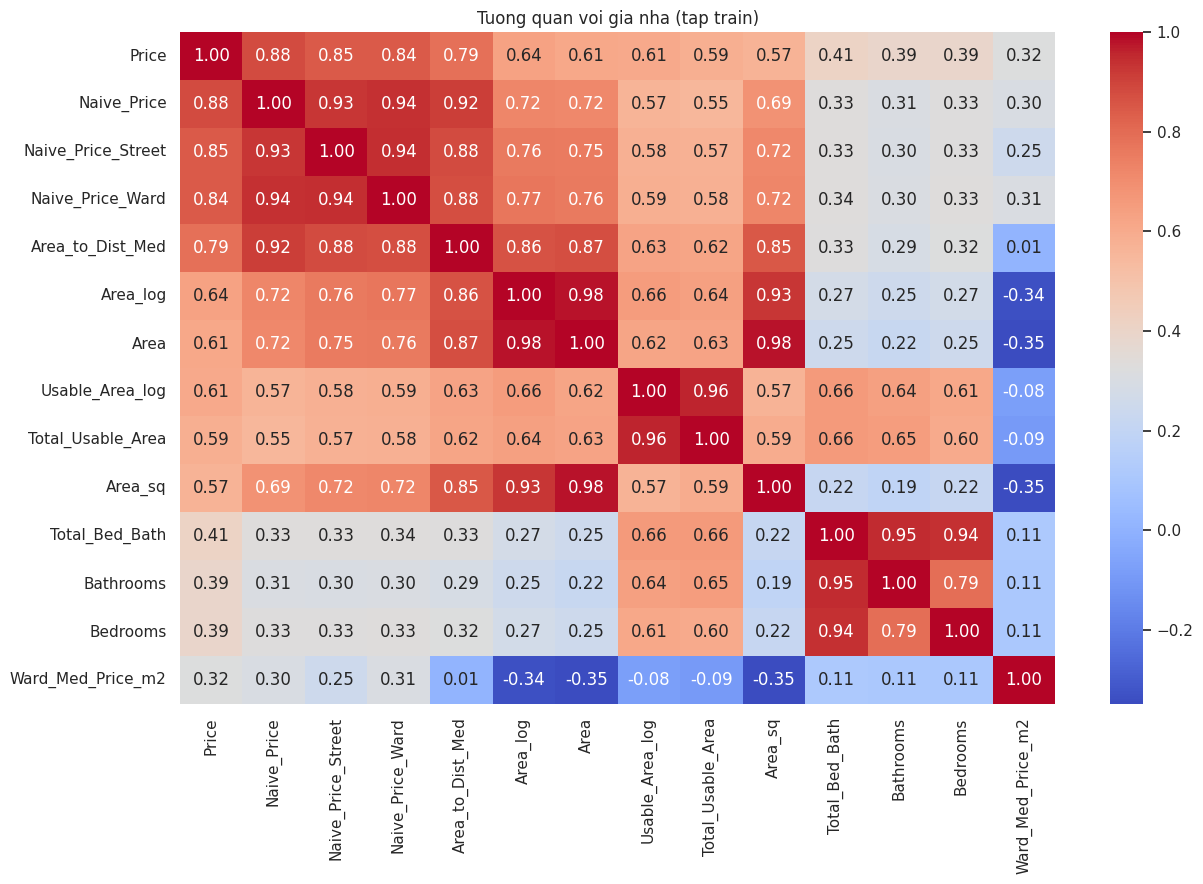

Price                 1.000000
Naive_Price           0.882621
Naive_Price_Street    0.845938
Naive_Price_Ward      0.844048
Area_to_Dist_Med      0.788290
Area_log              0.635562
Area                  0.614972
Usable_Area_log       0.608013
Total_Usable_Area     0.587161
Area_sq               0.571974
Total_Bed_Bath        0.414798
Bathrooms             0.392901
Name: Price, dtype: float64


In [ ]:
# 6. Ma tran tuong quan
plt.figure(figsize=(13, 9))
corr_df = train_fe[num_cols + [TARGET_COL]].copy()
corr = corr_df.corr()[TARGET_COL].sort_values(ascending=False)
top_cols = corr.index[:14]
sns.heatmap(corr_df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Tuong quan voi gia nha (tap train)')
plt.tight_layout()
plt.show()
print(corr.head(12))

In [14]:
# 7. Pipeline, mo hinh, danh gia
def build_preprocessor(num_cols, cat_cols):
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ])
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', TargetEncoder(smooth=20.0, cv=5, target_type='continuous')),
    ])
    return ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
    ])


def make_models(preprocessor, lgb_params=None):
    lgb_params = lgb_params or dict(
        n_estimators=1200, max_depth=8, learning_rate=0.025,
        num_leaves=63, subsample=0.85, colsample_bytree=0.85,
        min_child_samples=15, reg_alpha=0.05, reg_lambda=0.1,
        random_state=42, verbose=-1,
    )
    return {
        'LightGBM': Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', LGBMRegressor(**lgb_params)),
        ]),
        'XGBoost': Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', XGBRegressor(
                n_estimators=1200, max_depth=7, learning_rate=0.025,
                subsample=0.85, colsample_bytree=0.85,
                reg_alpha=0.05, reg_lambda=0.5,
                random_state=42, tree_method='hist', n_jobs=-1,
            )),
        ]),
        'CatBoost': Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', CatBoostRegressor(
                iterations=1200, depth=8, learning_rate=0.025,
                l2_leaf_reg=3, random_state=42, verbose=0,
                thread_count=-1, allow_writing_files=False,
            )),
        ]),
    }


def metrics_price(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE (ty VND)': mean_absolute_error(y_true, y_pred),
        'RMSE (ty VND)': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE %': float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100),
    }


preprocessor = build_preprocessor(num_cols, cat_cols)
models = make_models(preprocessor)

rows, fitted = [], {}
for name, pipe in models.items():
    print(f'Dang train {name} ...')
    pipe.fit(X_train, y_train_log)
    fitted[name] = pipe
    pred = np.expm1(pipe.predict(X_test))
    row = metrics_price(y_test_price, pred)
    row['Mo hinh'] = name
    rows.append(row)
    print(f"  {name}: R2={row['R2']:.4f} | MAE={row['MAE (ty VND)']:.4f} | RMSE={row['RMSE (ty VND)']:.4f}")

eval_df = pd.DataFrame(rows).sort_values('RMSE (ty VND)')
display(eval_df)

Dang train LightGBM ...
  LightGBM: R2=0.8459 | MAE=0.5369 | RMSE=0.6984
Dang train XGBoost ...
  XGBoost: R2=0.8474 | MAE=0.5365 | RMSE=0.6950
Dang train CatBoost ...
  CatBoost: R2=0.8447 | MAE=0.5522 | RMSE=0.7011


,R2,MAE (ty VND),RMSE (ty VND),MAPE %,Mo hinh
1,0.847425,0.536521,0.694998,9.138872,XGBoost
0,0.845934,0.536890,0.698385,9.148365,LightGBM
2,0.844736,0.552222,0.701095,9.356645,CatBoost


In [ ]:
# 10. Chon mo hinh tot nhat theo RMSE
best_row = eval_df.iloc[0]
best_name = best_row['Mo hinh']
best_model = fitted[best_name]
best_pred = np.expm1(best_model.predict(X_test))

print(f"Best: {best_name}")
print(f"R2   = {best_row['R2']:.4f}")
print(f"MAE  = {best_row['MAE (ty VND)']:.4f} tỷ")
print(f"RMSE = {best_row['RMSE (ty VND)']:.4f} tỷ")
print(f"MAPE = {best_row['MAPE %']:.2f}%")

Best: XGBoost
R2   = 0.8470
MAE  = 0.5376 tỷ
RMSE = 0.6961 tỷ
MAPE = 9.13%


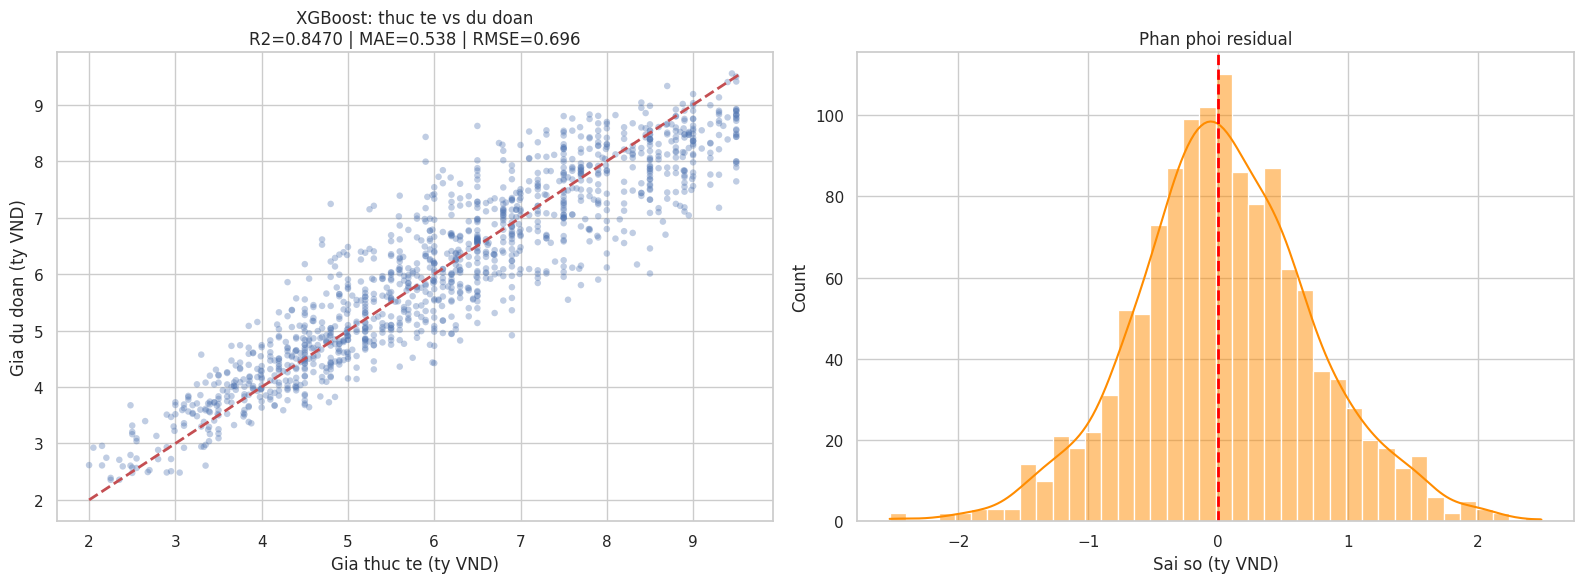

In [ ]:
# 11. Bieu do thuc te vs du doan + residual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_test_price, best_pred, alpha=0.35, s=22, edgecolors='none')
lo = min(y_test_price.min(), best_pred.min())
hi = max(y_test_price.max(), best_pred.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2)
axes[0].set_xlabel('Gia thuc te (ty VND)')
axes[0].set_ylabel('Gia du doan (ty VND)')
axes[0].set_title(f'{best_name}: thuc te vs du doan\nR2={best_row["R2"]:.4f} | MAE={best_row["MAE (ty VND)"]:.3f} | RMSE={best_row["RMSE (ty VND)"]:.3f}')

resid = y_test_price - best_pred
sns.histplot(resid, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Sai so (ty VND)')
axes[1].set_title('Phan phoi residual')
plt.tight_layout()
plt.show()

In [ ]:
# 12. Sai so theo loai hinh va quan
err = test_fe[['District', 'Property_Type', 'Is_Alley']].copy()
err['y'] = y_test_price.to_numpy()
err['pred'] = best_pred
err['abs_err'] = (err['y'] - err['pred']).abs()

def _err_summary(g):
    return pd.Series({
        'n': len(g),
        'MAE': mean_absolute_error(g['y'], g['pred']),
        'RMSE': float(np.sqrt(mean_squared_error(g['y'], g['pred']))),
    })

print('MAE theo loai hinh:')
display(err.groupby('Property_Type', group_keys=False).apply(_err_summary, include_groups=False).reset_index())

print('Top quan MAE cao:')
by_dist = (
    err.groupby('District', group_keys=False)
       .apply(_err_summary, include_groups=False)
       .reset_index()
       .sort_values('MAE', ascending=False)
)
display(by_dist.head(8))

MAE theo loai hinh:


,Property_Type,n,MAE,RMSE
0,house,1261.0,0.537615,0.696072


Top quan MAE cao:


,District,n,MAE,RMSE
15,Quận 5,8.0,0.764128,0.927723
9,Quận 10,30.0,0.718594,0.871187
10,Quận 11,19.0,0.679731,0.843522
7,Phú Nhuận,37.0,0.653000,0.794912
18,Quận 8,41.0,0.596067,0.788575
21,Tân Bình,94.0,0.580654,0.750277
17,Quận 7,67.0,0.570929,0.741922
16,Quận 6,30.0,0.553427,0.684242


In [ ]:
# 13. Luu model
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
payload = {
    'version': 2,
    'model': best_model,
    'model_name': f'{best_name}',
    'features': num_cols + cat_cols,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'target_type': 'log_price',
    'district_median_areas': stats['district_median_areas'],
    'impute_district': stats['impute_district'],
    'impute_global': stats['impute_global'],
    'dist_price_m2': stats['dist_price_m2'],
    'ward_price_m2': stats['ward_price_m2'],
    'street_price_m2': stats['street_price_m2'],
    'global_price_m2': stats['global_price_m2'],
    'rare_streets': stats['rare_streets'],
    'rel_max': REL_MAX,
    'r2_score': float(best_row['R2']),
    'mae': float(best_row['MAE (ty VND)']),
    'rmse': float(best_row['RMSE (ty VND)']),
    'mape': float(best_row['MAPE %']),
}
joblib.dump(payload, MODEL_SAVE_PATH)
print('Da luu:', MODEL_SAVE_PATH)
print(f"- Mo hinh: {payload['model_name']}")
print(f"- R2={payload['r2_score']:.4f} | MAE={payload['mae']:.4f} | RMSE={payload['rmse']:.4f}")

Da luu: e:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\models\best_model_v2.pkl
- Mo hinh: XGBoost
- R2=0.8470 | MAE=0.5376 | RMSE=0.6961
